파이토치 환경 확인

In [1]:
import torch
print('PyTorch:', torch.__version__)
print('CUDA 사용 가능:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.6.0+cu124
CUDA 사용 가능: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


# 사이킷런 다운로드

In [2]:
!pip install -U scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -------------------------------- ------- 6.6/8.1 MB 30.8 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 29.4 MB/s  0:00:00

   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   --------------------------

# import torch

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader


# 1. 재현성 고정, 2. 데이터 로드

In [6]:
# 1. 재현성 고정
torch.manual_seed(1)

# 2. 데이터 로드
lris = load_iris()
X = lris.data
y = lris.target 
X.shape, y.shape  


((150, 4), (150,))

# 3 train/test 분할

In [7]:
# 3. train/test 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)  


# 4 X값 스케일링 - array, 사이킷런 라이브러리

In [12]:
# 4. X값 스케일링 - array, 사이킷런 라이브러리
scaler = StandardScaler()   
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)


# 5 Tensor 변환

In [9]:
# 5. Tensor 변환
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# 6 Dataset / DataLoader

In [11]:
# 6. Dataset / DataLoader 
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)  

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)  

# 7. 신경망 모델 정의

In [10]:
# 7. 신경망 모델 정의
class IrisNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 16) # 입력 특성 4개
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 3) # 출력 클래스 3개

    def forward(self, x): #순방향학습
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# 8. 모델, 손실함수, 최적화 알고리즘 정의

In [17]:
model = IrisNet()
model

IrisNet(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=3, bias=True)
)

In [18]:
# 8. 모델, 손실함수와 옵티마이저
criterion = nn.CrossEntropyLoss()     
optimizer = optim.Adam(model.parameters(), lr=0.01)


# 9. 학습 루프

In [24]:
# 9. 모델 학습
num_epochs = 100    
loss_history = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0 

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()          # <- 이 줄이 빠져있었음

    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')


Epoch [10/100], Loss: 0.0631
Epoch [20/100], Loss: 0.0682
Epoch [30/100], Loss: 0.0652
Epoch [40/100], Loss: 0.0660
Epoch [50/100], Loss: 0.0670
Epoch [60/100], Loss: 0.0637
Epoch [70/100], Loss: 0.0753
Epoch [80/100], Loss: 0.0684
Epoch [90/100], Loss: 0.0697
Epoch [100/100], Loss: 0.0807


# 10. 모델 평가

In [25]:
# 10. 모델 평가
model.eval()      
correct = 0
total = 0

with torch.no_grad():  
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)  
        _, predicted = torch.max(outputs.data, 1)  
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()  

accuracy = 100 * correct / total
print(f'Accuracy: {100 * correct / total:.2f}%')  

Accuracy: 100.00%


# 11. 예측 결과 확인

In [26]:
# 11. 예측 결과 확인
with torch.no_grad():
    sample = torch.FloatTensor(X_test[0]).unsqueeze(0)  
    output = model(sample)  
    predicted_class = torch.argmax(output, dim=1).item()  
    actual_class = int(y_test[0]) if isinstance(y_test[0], (int, float)) else y_test[0].item()
    print(f'예측된 클래스: {predicted_class}, 실제 클래스: {actual_class}')


예측된 클래스: 2, 실제 클래스: 2


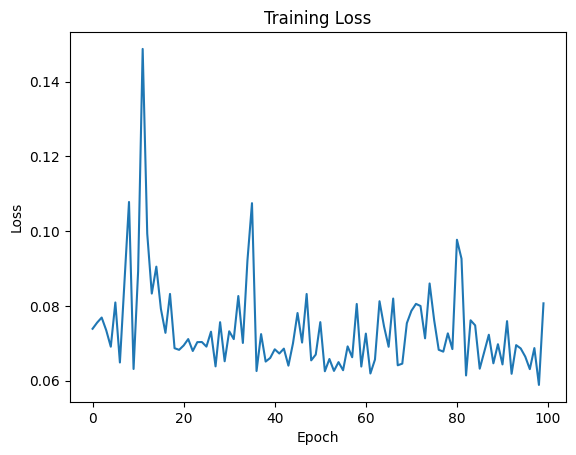

In [27]:
import matplotlib.pyplot as plt
plt.plot(loss_history)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')  
plt.show()

# PyTorch 연습

In [28]:
!pip install torchsummary

# 1. 환경 확인

In [29]:
# 1. 환경 확인
import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch: 2.6.0+cu124
CUDA available: True
Using device: cuda


# 2. 데이터셋 로드

In [30]:
# 2. 데이터셋 로드
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

100%|██████████| 9.91M/9.91M [00:09<00:00, 1.05MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 147kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.38MB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]


# 3. 모델 정의

In [32]:
# 3. 모델 정의
import torch.nn as nn
import torch.nn.functional as F

class MnistNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

model = MnistNet().to(device) 

# 3. CNN 변환

In [39]:
import torch.nn as nn
import torch.nn.functional as F

class MnistCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 🔷 특징 추출부 (Convolution)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # 1채널→32채널
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # 32채널→64채널
        self.pool  = nn.MaxPool2d(2, 2)                          # 크기 절반으로 축소

        # 🔷 분류부 (Fully Connected)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)  # 64채널 × 7×7
        self.fc2 = nn.Linear(128, 10)           # 10개 숫자(0~9) 분류

    def forward(self, x):
        # Conv → ReLU → Pooling (28×28 → 14×14)
        x = self.pool(F.relu(self.conv1(x)))
        # Conv → ReLU → Pooling (14×14 → 7×7)
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(-1, 64 * 7 * 7)  # Flatten
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = MnistCNN().to(device)
print(model)



MnistCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


# 4. 손실함수와 옵티마이저

In [33]:
# 4. 손실함수와 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 5. 학습 루프

In [35]:
# 5. 학습 루프
epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/10, Loss: 0.0930
Epoch 2/10, Loss: 0.0829
Epoch 3/10, Loss: 0.0703
Epoch 4/10, Loss: 0.0620
Epoch 5/10, Loss: 0.0531
Epoch 6/10, Loss: 0.0497
Epoch 7/10, Loss: 0.0437
Epoch 8/10, Loss: 0.0414
Epoch 9/10, Loss: 0.0404
Epoch 10/10, Loss: 0.0349


# 6. 평가

In [36]:
# 6. 평가
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y).sum().item()
        total += y.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 97.85%
